## ModClark Parameters Optimization

This notebook details the process for optimizing the ModClark Instantaneous Unit Hydrograph (IUH) parameters, $T_c$ and $R$. The optimization methodology adheres to the principles outlined in [the main documentation](../../README.MD).

During the precipitation data preprocessing, an ambiguity arose regarding the time standard (UTC vs. local time) of the input data. To address this, two distinct preprocessed datasets were generated: one assuming UTC timestamps and another assuming local time. The local time definition was derived from the precipitation station metadata, which includes a UTC offset column.

---

Prior to optimizing parameters for all selected storm events, a preliminary analysis will be conducted. A subset of 10 randomly selected events from 30 random watersheds will be optimized using both the UTC and local time datasets. The dataset yielding a superior average Nash-Sutcliffe Efficiency (NSE) will be adopted as the correct time standard for subsequent optimizations.

Initial observations suggest that the precipitation data is more likely recorded in local time. This is indicated by a noticeable delay in the hydrological response when the UTC precipitation dataset is used. The comparative average NSE values for each dataset will ultimately determine which dataset is utilized for the full optimization.

In [4]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import sys
from tqdm.notebook import tqdm
from pysheds.grid import Grid
from matplotlib import pyplot as plt
import os
from time import sleep

In [5]:
# Custom Modules
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT / 'src'))

from hydrology.modclark_model import ModClarkModel
from utils.data_utils import glimpse
from plotting_functions.hydrograph import *

### Load and Analyze Storm Events Metada
#### UTC Time Standard

In [ ]:
# Load events metadata
events_metadata_utc_path = PROJECT_ROOT / 'data/gold/tabular/detected_storm_events.parquet'
storm_events_utc_metadata = pd.read_parquet(events_metadata_utc_path)

In [ ]:
# Analyze storm events metadata
glimpse(storm_events_utc_metadata)

In [ ]:
print(f"\nTotal number of storm events: {len(storm_events_utc_metadata)}")
storm_events_utc_metadata['ws_id'] = storm_events_utc_metadata['storm_id'].str.split('_').str[0]
unique_watersheds = storm_events_utc_metadata['ws_id'].unique()
print(f"Number of unique watersheds: {len(unique_watersheds)}")
print(f"\nDistribution of storm events per watershed:")
print(storm_events_utc_metadata.groupby('ws_id').size().reset_index(name='event_count')['event_count'].describe().round(0))
avg_events_per_watershed = storm_events_utc_metadata.groupby('ws_id').size().mean()
print(f"\nNumber of watersheds with less than 10 storm events: {storm_events_utc_metadata.groupby('ws_id').size()[storm_events_utc_metadata.groupby('ws_id').size() < 10].count()}")
print(f"Number of watersheds with less than 5 storm events: {storm_events_utc_metadata.groupby('ws_id').size()[storm_events_utc_metadata.groupby('ws_id').size() < 5].count()}")
print(f"Average response time (in minutes): {storm_events_utc_metadata['response_min'].mean():.2f}")
print(f"Average precipitation duration (in minutes): {storm_events_utc_metadata['ppt_dutation_min'].mean():.2f}")
print(f"Number of storm events with response time > 60 minutes: {storm_events_utc_metadata[storm_events_utc_metadata['response_min'] > 60].shape[0]}")
print(f"Number of watershed with response time > 60 minutes: {storm_events_utc_metadata[storm_events_utc_metadata['response_min'] > 60]['ws_id'].nunique()}")
print(f"Number of storm watersheds with response time no more than 30 minutes: {storm_events_utc_metadata[storm_events_utc_metadata['response_min'] <= 30]['ws_id'].nunique()}")
print(f"Number of watersheds with more than 1 precipitation station: {storm_events_utc_metadata[storm_events_utc_metadata['n_ppt_stations'] > 1]['ws_id'].nunique()}")
print(f"Number of storm events with no precipitation after peakflow: {storm_events_utc_metadata[storm_events_utc_metadata['total_ppt_after_peak_mm'] == 0].shape[0]}")
print(f"Number of watersheds  with no precipitation after peakflow: {storm_events_utc_metadata[storm_events_utc_metadata['total_ppt_after_peak_mm'] == 0]['ws_id'].nunique()}")

print(f"""
Distribution of storm events per watershed that follows the criteria:
    - Number of storm events per watershed >= 5
    - Response time <= 30 minutes
    - Total precipitation after peakflow = 0 mm
      """)
filtered_storm_events_utc_metada = storm_events_utc_metadata[(storm_events_utc_metadata['response_min'] <= 30) & 
                                             (storm_events_utc_metadata['total_ppt_after_peak_mm'] == 0)]
filtered_storm_events_utc_metada = filtered_storm_events_utc_metada.groupby('ws_id').filter(lambda x: len(x) >= 5)
print(filtered_storm_events_utc_metada.groupby('ws_id').size().reset_index(name='event_count')['event_count'].describe().round(0))

print(f"\nNumber of storm events that follow the criteria: {len(filtered_storm_events_utc_metada)}")




Total number of storm events: 62258
Number of unique watersheds: 461

Distribution of storm events per watershed:
count    461.0
mean     135.0
std      107.0
min        2.0
25%       57.0
50%      109.0
75%      190.0
max      571.0
Name: event_count, dtype: float64

Number of watersheds with less than 10 storm events: 17
Number of watersheds with less than 5 storm events: 7
Average response time (in minutes): 69.18
Average precipitation duration (in minutes): 1923.81
Number of storm events with response time > 60 minutes: 608
Number of watershed with response time > 60 minutes: 191
Number of storm watersheds with response time no more than 30 minutes: 437
Number of watersheds with more than 1 precipitation station: 83
Number of storm events with no precipitation after peakflow: 18557
Number of watersheds  with no precipitation after peakflow: 456

Distribution of storm events per watershed that follows the criteria:
    - Number of storm events per watershed >= 5
    - Response time

#### Local Time Standard

In [ ]:
# Load events metadata
events_metadata_tz_offset_path = PROJECT_ROOT / 'data/gold/tabular/detected_storm_events_tz_offset.parquet'
storm_events_tz_offset_metadata = pd.read_parquet(events_metadata_tz_offset_path)

In [ ]:
print(f"\nTotal number of storm events: {len(storm_events_tz_offset_metadata)}")
storm_events_tz_offset_metadata['ws_id'] = storm_events_tz_offset_metadata['storm_id'].str.split('_').str[0]
unique_watersheds = storm_events_tz_offset_metadata['ws_id'].unique()
print(f"Number of unique watersheds: {len(unique_watersheds)}")
print(f"\nDistribution of storm events per watershed:")
print(storm_events_tz_offset_metadata.groupby('ws_id').size().reset_index(name='event_count')['event_count'].describe().round(0))
avg_events_per_watershed = storm_events_tz_offset_metadata.groupby('ws_id').size().mean()
print(f"\nNumber of watersheds with less than 10 storm events: {storm_events_tz_offset_metadata.groupby('ws_id').size()[storm_events_tz_offset_metadata.groupby('ws_id').size() < 10].count()}")
print(f"Number of watersheds with less than 5 storm events: {storm_events_tz_offset_metadata.groupby('ws_id').size()[storm_events_tz_offset_metadata.groupby('ws_id').size() < 5].count()}")
print(f"Average response time (in minutes): {storm_events_tz_offset_metadata['response_min'].mean():.2f}")
print(f"Average precipitation duration (in minutes): {storm_events_tz_offset_metadata['ppt_dutation_min'].mean():.2f}")
print(f"Number of storm events with response time > 60 minutes: {storm_events_tz_offset_metadata[storm_events_tz_offset_metadata['response_min'] > 60].shape[0]}")
print(f"Number of watershed with response time > 60 minutes: {storm_events_tz_offset_metadata[storm_events_tz_offset_metadata['response_min'] > 60]['ws_id'].nunique()}")
print(f"Number of storm watersheds with response time no more than 30 minutes: {storm_events_tz_offset_metadata[storm_events_tz_offset_metadata['response_min'] <= 30]['ws_id'].nunique()}")
print(f"Number of watersheds with more than 1 precipitation station: {storm_events_tz_offset_metadata[storm_events_tz_offset_metadata['n_ppt_stations'] > 1]['ws_id'].nunique()}")
print(f"Number of storm events with no precipitation after peakflow: {storm_events_tz_offset_metadata[storm_events_tz_offset_metadata['total_ppt_after_peak_mm'] == 0].shape[0]}")
print(f"Number of watersheds  with no precipitation after peakflow: {storm_events_tz_offset_metadata[storm_events_tz_offset_metadata['total_ppt_after_peak_mm'] == 0]['ws_id'].nunique()}")

print(f"""
Distribution of storm events per watershed that follows the criteria:
    - Number of storm events per watershed >= 5
    - Response time <= 30 minutes
    - Total precipitation after peakflow = 0 mm
      """)
filtered_storm_events_tz_offset_metada = storm_events_tz_offset_metadata[(storm_events_tz_offset_metadata['response_min'] <= 30) & 
                                             (storm_events_tz_offset_metadata['total_ppt_after_peak_mm'] == 0)]
filtered_storm_events_tz_offset_metada = filtered_storm_events_tz_offset_metada.groupby('ws_id').filter(lambda x: len(x) >= 5)
print(filtered_storm_events_tz_offset_metada.groupby('ws_id').size().reset_index(name='event_count')['event_count'].describe().round(0))

print(f"\nNumber of storm events that follow the criteria: {len(filtered_storm_events_tz_offset_metada)}")




Total number of storm events: 81672
Number of unique watersheds: 461

Distribution of storm events per watershed:
count    461.0
mean     177.0
std      132.0
min        4.0
25%       75.0
50%      150.0
75%      254.0
max      709.0
Name: event_count, dtype: float64

Number of watersheds with less than 10 storm events: 12
Number of watersheds with less than 5 storm events: 3
Average response time (in minutes): 89.48
Average precipitation duration (in minutes): 1906.67
Number of storm events with response time > 60 minutes: 954
Number of watershed with response time > 60 minutes: 251
Number of storm watersheds with response time no more than 30 minutes: 439
Number of watersheds with more than 1 precipitation station: 83
Number of storm events with no precipitation after peakflow: 21904
Number of watersheds  with no precipitation after peakflow: 456

Distribution of storm events per watershed that follows the criteria:
    - Number of storm events per watershed >= 5
    - Response time

To reduce computational demand, storm events that did not meet specific quality criteria were excluded from the modeling process. The exclusion criteria were as follows:

1.  **No precipitation after peak flow:** This criterion ensures more uniform hydrograph shapes, indicating a clearer single-event response.
2.  **Response time less than or equal to 30 minutes:** A 30-minute threshold is considered a reasonable minimum for a watershed's hydrological response. Events with a response time greater than 30 minutes were likely indicative of data misalignment or spatial variability not adequately captured by the precipitation stations.
3.  **Watersheds with fewer than 5 storm events:** After applying the first two criteria, watersheds with an insufficient number of remaining storm events (fewer than 5) were also excluded from the study.

This filtering process significantly reduced the dataset size: the total number of events to optimize decreased from **62,200 to 17,200** for the UTC dataset and from **81,600 para 20,200**. However, the number of watersheds also decreased, from **461 to 406** for UTC dataset and to **412** for Local Time dataset. 


### Preprocessing

The ModClarks IUH, requires a distance to outlet grid, to compute the time area histogram. The code in this section computes the distance to outlet for each watershed and saves it locally for using it during the modeling process. 

In [8]:
# Define functions

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import rasterio.warp
from pathlib import Path
from tqdm import tqdm
from shapely import wkt
from pysheds.grid import Grid

# --- Constants ---
D8_DIRMAP = (64, 128, 1, 2, 4, 8, 16, 32)

# --- Helper Functions (Moved from main script) ---

def create_distance_weights(resolution: float, fdir: np.ndarray) -> np.ndarray:
    """Creates a weights grid for calculating geometric distance in pysheds."""
    cardinal_dirs = (64, 1, 4, 16)
    diagonal_dirs = (128, 2, 8, 32)
    cardinal_dist = resolution
    diagonal_dist = np.sqrt(2) * resolution
    weights_grid = np.full_like(fdir, 0, dtype=np.float64)
    weights_grid[np.isin(fdir, cardinal_dirs)] = cardinal_dist
    weights_grid[np.isin(fdir, diagonal_dirs)] = diagonal_dist
    return weights_grid

def compute_distance_grid(grid: 'Grid', fdir: np.ndarray, resolution: float, pour_point: tuple) -> np.ndarray:
    """Computes a distance grid based on the flow direction grid."""
    x, y = pour_point
    weights = create_distance_weights(resolution, fdir)
    dist = grid.distance_to_outlet(
        x=x, y=y, fdir=fdir, dirmap=D8_DIRMAP, xytype='coordinate', weights=weights
    )
    return dist

def get_pour_point(vector_catch: gpd.GeoDataFrame) -> tuple[float, float]:
    """Extracts the pour point coordinates."""
    point_string = vector_catch['snapped_pour_point_nad83'].iloc[0]
    coordinates = wkt.loads(point_string)
    return (coordinates.x, coordinates.y)

def get_resolution_from_raster(ws_id: str, project_root_path: Path, target_crs: str) -> tuple[float, float]:
    """Gets the resolution of a flow direction raster."""
    flowdir_path = project_root_path / f"data/silver/geo/raster/watersheds/flowdir_{ws_id}.tif"
    with rasterio.open(flowdir_path) as src:
        transform, _, _ = rasterio.warp.calculate_default_transform(
            src.crs, target_crs, src.width, src.height, *src.bounds
        )
    return (transform[0], transform[4])

# --- Main Preprocessing Function ---

def preprocess_and_save_distance_grid(ws_id: str, project_root: Path, display=False):
    """
    Computes and saves the distance-to-outlet grid for a watershed as a .npy file.
    """
    if display:
        print(f"Preprocessing distance grid for watershed: {ws_id}...")
    try:
        # Define I/O paths
        ws_raster_dir = project_root / "data/silver/geo/raster/watersheds"
        ws_vector_dir = project_root / 'data/silver/geo/gpkg/watersheds'
        output_dir = project_root / "data/gold/geo/raster/watersheds"
        output_dir.mkdir(parents=True, exist_ok=True) # Ensure output directory exists

        flowdir_path = ws_raster_dir / f"flowdir_{ws_id}.tif"
        ws_mask_path = ws_raster_dir / f"catchment_{ws_id}.tif"
        vector_catch_path = ws_vector_dir / f'catchment_{ws_id}.gpkg'
        output_path = output_dir / f"distance_grid_{ws_id}.npy"

        # 1. Load necessary geo-data
        vector_catch = gpd.read_file(vector_catch_path)
        grid = Grid.from_raster(str(flowdir_path), data_name='flowdir')
        fdir = grid.read_raster(str(flowdir_path), dtype=np.float32)
        catch_mask = grid.read_raster(str(ws_mask_path), dtype=np.float32)
        grid.clip_to(catch_mask)

        # 2. Get parameters for distance calculation
        pour_point = get_pour_point(vector_catch)
        target_crs = vector_catch.crs
        x_res, _ = get_resolution_from_raster(ws_id, project_root, target_crs)
        resolution_m = abs(x_res)

        # 3. Compute the distance grid
        distance_grid = compute_distance_grid(grid, fdir, resolution_m, pour_point)

        # 4. Save the final grid as a .npy file
        np.save(output_path, distance_grid)
        if display:
            print(f"  -> Successfully saved to {output_path}")

    except Exception as e:
        print(f"  -> ERROR: Failed to preprocess {ws_id}: {e}")

if __name__ == '__main__':
    # --- Setup ---
    # Define the project root and output directory
    output_dir = PROJECT_ROOT / "data/gold/geo/raster/watersheds"
    
    # Ensure the output directory exists
    output_dir.mkdir(parents=True, exist_ok=True)

    # --- 1. Get a list of all watershed IDs that need processing ---
    utc_metadata_path = PROJECT_ROOT / 'data/gold/tabular/detected_storm_events.parquet'
    utc_metadata = pd.read_parquet(utc_metadata_path)
    utc_metadata['ws_id'] = utc_metadata['storm_id'].str.split('_').str[0]
    all_watershed_ids = utc_metadata['ws_id'].unique()

    # --- 2. Find watersheds that have already been processed ---
    # List files in the output directory and extract the ws_id from each filename
    processed_ws_ids = {
        f.replace('distance_grid_', '').replace('.npy', '') 
        for f in os.listdir(output_dir) if f.startswith('distance_grid_') and f.endswith('.npy')
    }

    # --- 3. Determine which watersheds to process now ---
    # Exclude the already processed watersheds from the main list
    ws_to_process = [ws_id for ws_id in all_watershed_ids if ws_id not in processed_ws_ids]

    print(f"Found {len(all_watershed_ids)} total watersheds.")
    print(f"Found {len(processed_ws_ids)} already processed grids. Skipping them.")
    print(f"--- Starting preprocessing for {len(ws_to_process)} remaining watersheds ---")

    # --- 4. Run preprocessing only on the remaining watersheds ---
    if ws_to_process:
        for ws_id in tqdm(ws_to_process, desc="Preprocessing Watersheds"):
            preprocess_and_save_distance_grid(ws_id, PROJECT_ROOT)
            sleep(0.5)

    
    print("--- Preprocessing Complete ---")

Found 461 total watersheds.
Found 33 already processed grids. Skipping them.
--- Starting preprocessing for 428 remaining watersheds ---


Preprocessing Watersheds:   0%|          | 0/428 [00:00<?, ?it/s]

: 

### $R$ and $T_c$ Parameter Optimization

Run optmization on both dataset for comparison which one yields the best model fit. Once the data set is defined, optmization will run on the all the same storm events with three different optmizations parameters:

1. With geo characteristics parameters to set the boundaries of $T_c$ and $R$
2. With computed bound for $Initial loss$ and $Constant loss$ for precipitation loss parameters.
3. With both computed boundaries for $T_c$ and $R$ and for $Initial loss$ and $Constant loss$.

The chosen method to optmize the whole dataset of storm evetns will be chosen from the best method above based on the NSE coefficient. 

#### Compare sample watershed optmization between datasets

In [5]:
import random
import rasterio
import numpy as np

# --- Constants ---
D8_DIRMAP = (64, 128, 1, 2, 4, 8, 16, 32)

# --- Function Definitions ---
def select_n_random_watersheds(
    dataset1: pd.DataFrame,
    dataset2: pd.DataFrame,
    n_watersheds: int = 30,
    n_events: int = 10,
    distance_grid_path: Path = None
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Selects a random sample of watersheds and storm events from two metadata datasets.

    This function first filters both datasets to include only watersheds with a minimum
    number of events. Then, it randomly selects 'n_watersheds' and, for each of
    those, randomly selects 'n_events'. Optionally it excludes watersheds with no distance grid computed.

    Args:
        dataset1: The first metadata DataFrame, containing 'ws_id' and 'storm_id'.
        dataset2: The second metadata DataFrame, with a similar structure to dataset1.
        n_watersheds: The number of unique watersheds to sample.
        n_events: The number of storm events to sample for each watershed.
        distance_grid_path: The path to the directory containing the distance grid.

    Returns:
        A tuple containing two DataFrames:
        - selected_events1: Sampled events from the first dataset.
        - selected_events2: Sampled events from the second dataset.
        
    Raises:
        ValueError: If a different number of watersheds are selected from the datasets
                    or if the requested number of watersheds is greater than available.
    """
    if distance_grid_path is not None:
        distance_grid_path = Path(distance_grid_path)
        if distance_grid_path.is_dir():
            files = distance_grid_path.glob('*.npy')
            distance_grid_ws_ids = {f.stem.replace('distance_grid_', '') for f in files} # Use a set
            dataset1 = dataset1[dataset1['ws_id'].isin(distance_grid_ws_ids)]
            dataset2 = dataset2[dataset2['ws_id'].isin(distance_grid_ws_ids)]

    # Filter for watersheds with at least n_events
    ws_group1 = dataset1.groupby('ws_id')
    ws_group2 = dataset2.groupby('ws_id')
    dataset1_filtered = ws_group1.filter(lambda x: x['storm_id'].nunique() >= n_events)
    dataset2_filtered = ws_group2.filter(lambda x: x['storm_id'].nunique() >= n_events)

    # Find common watersheds after filtering
    unique_ws1 = set(dataset1_filtered['ws_id'].unique())
    unique_ws2 = set(dataset2_filtered['ws_id'].unique())
    common_ws_ids = list(unique_ws1.intersection(unique_ws2))

    if n_watersheds > len(common_ws_ids):
        raise ValueError(
            f"Requested {n_watersheds} watersheds, but only {len(common_ws_ids)} "
            f"are available in both datasets with at least {n_events} events."
        )

    # Sample from the common watersheds
    random.seed(41)
    sampled_ws_ids = random.sample(common_ws_ids, n_watersheds)

    sampled_df1 = dataset1[dataset1['ws_id'].isin(sampled_ws_ids)].copy()
    sampled_df2 = dataset2[dataset2['ws_id'].isin(sampled_ws_ids)].copy()

    # It's good practice to double-check that the filtered sets are equal
    if len(sampled_df1['ws_id'].unique()) != len(sampled_df2['ws_id'].unique()):
        raise ValueError("A different number of watersheds was selected between datasets.")

    # Group by watershed and sample n_events for each
    selected_events1 = (
        sampled_df1.groupby('ws_id')['storm_id']
        .apply(lambda x: x.drop_duplicates().sample(n=n_events, random_state=42))
        .reset_index()
    )
    selected_events2 = (
        sampled_df2.groupby('ws_id')['storm_id']
        .apply(lambda x: x.drop_duplicates().sample(n=n_events, random_state=42))
        .reset_index()
    )

    # Merge back to get other event data like start/end times
    event_cols = ['storm_id', 'event_start', 'event_end']
    selected_events1 = selected_events1.merge(
        dataset1[event_cols].drop_duplicates(), on='storm_id'
    )
    selected_events2 = selected_events2.merge(
        dataset2[event_cols].drop_duplicates(), on='storm_id'
    )

    return selected_events1, selected_events2

def load_files(
    ws_id: str,
    project_root_path: Path
    ) -> tuple:
    """
    Loads all necessary vector, raster, and tabular files for a given watershed.

    Args:
        ws_id: The watershed identifier.
        project_root_path: The root path of the project directory (as a Path object).
        tz_offset: Boolean flag to load the timezone-offset hydrological data.

    Returns:
        A tuple containing:
        - vector_catch (GeoDataFrame)
        - lined_up_data_utc (DataFrame)
        - lined_up_data_tz_offset (DataFrame)
    """
    # Define folder paths from the project root
    ws_vector_dir = project_root_path / 'data/silver/geo/gpkg/watersheds'
    hydrological_data_dir = project_root_path / 'data/gold/tabular/lined_up_data'

    # Define file paths
    vector_catch_path = ws_vector_dir / f'catchment_{ws_id}.gpkg'
    geo_characteristics_path = project_root_path / 'data/gold/tabular/geomorphological_characteristics.csv'
    
    lined_up_data_path_tz_offset = hydrological_data_dir / f'ws_{ws_id}_tz_offset.parquet'
    lined_up_data_path_utc = hydrological_data_dir / f'ws_{ws_id}.parquet'

    # Load vector files
    vector_catch = gpd.read_file(vector_catch_path)

    # Load tabular data
    lined_up_data_tz_offset = pd.read_parquet(lined_up_data_path_tz_offset)
    lined_up_data_tz_offset = lined_up_data_tz_offset.set_index('date').sort_index()
    geo_characteristcs = pd.read_csv(geo_characteristics_path, dtype={'Station ID':str})
    geo_characteristcs = geo_characteristcs.set_index('Station ID')

    lined_up_data_utc = pd.read_parquet(lined_up_data_path_utc)
    lined_up_data_utc = lined_up_data_utc.set_index('date').sort_index()

    return vector_catch, lined_up_data_utc, lined_up_data_tz_offset, geo_characteristcs


def get_resolution_from_raster(ws_id: str, project_root_path: Path, target_crs: str) -> tuple[float, float]:
    """
    Gets the resolution of a flow direction raster in the target CRS.

    Args:
        ws_id: The watershed identifier.
        project_root_path: The root path of the project directory.
        target_crs: The target Coordinate Reference System.

    Returns:
        A tuple of (x_resolution, y_resolution).
    """
    ws_raster_dir = project_root_path / "data/silver/geo/raster/watersheds"
    flowdir_path = ws_raster_dir / f"flowdir_{ws_id}.tif"

    with rasterio.open(flowdir_path) as src:
        transform, _, _ = rasterio.warp.calculate_default_transform(
            src.crs, target_crs, src.width, src.height, *src.bounds
        )
    # transform[0] is pixel width (x_res), transform[4] is pixel height (y_res)
    return (transform[0], transform[4])


# --- Function to load pre-computed grid ---
def load_distance_grid(ws_id: str, project_root: Path) -> np.ndarray:
    """
    Loads a pre-computed distance grid from a .npy file.
    
    Args:
        ws_id: The watershed identifier.
        project_root: The root path of the project directory.

    Returns:
        A numpy array of the distance grid.
    
    Raises:
        FileNotFoundError: If the pre-computed file does not exist.
    """
    distance_grid_path = project_root / f"data/gold/geo/raster/watersheds/distance_grid_{ws_id}.npy"
    if not distance_grid_path.exists():
        raise FileNotFoundError(
            f"Distance grid not found: {distance_grid_path}. "
            "Please run the `preprocess_grids.py` script first."
        )
    return np.load(distance_grid_path)

# Main comparison function ---
def compare_datasets_optimization(
    utc_metadata: pd.DataFrame,
    tz_offset_metadata: pd.DataFrame,
    project_root: Path,
    n_ws: int,
    n_ev: int,
    display: bool = True
) -> tuple[dict, dict, dict]: # Added dict for dummy, adjust if needed
    """
    Compares Nash-Sutcliffe Efficiency (NSE) for watersheds from two datasets,
    also collecting the storm_id for each optimized event.
    """
    nse_utc_scores = {}
    nse_tz_offset_scores = {}
    dummy = {}

    delta_t = 900  # Time step in seconds
    distance_grid_dir = project_root / f"data/gold/geo/raster/watersheds/"
    storm_events_utc, storm_events_tz_offset = select_n_random_watersheds(
        utc_metadata, tz_offset_metadata, n_watersheds=n_ws, n_events=n_ev, distance_grid_path=distance_grid_dir
    )
    ws_ids = storm_events_utc['ws_id'].unique()

    for ws_id in tqdm(ws_ids, desc="Processing watersheds"):
        if display:
            print(f"--- Processing Watershed: {ws_id} ---")

        # Change these to store dictionaries for storm_id and NSE
        nse_utc_scores[ws_id] = [] 
        nse_tz_offset_scores[ws_id] = []
        dummy[ws_id] = []

        try:
            # Load hydrological data and vector file to get metadata
            vector_catch, lined_up_data_utc, lined_up_data_tz_offset, _ = load_files(ws_id, project_root)
            
            # Get necessary parameters
            target_crs = vector_catch.crs
            x_res, y_res = get_resolution_from_raster(ws_id, project_root, target_crs=target_crs)
            
            # --- Load the pre-computed distance grid ---
            distance_grid = load_distance_grid(ws_id, project_root)
            cell_area = abs(x_res * y_res)
            dummy[ws_id].append(False)
            
        except Exception as e:
            print(f"    Skipping watershed {ws_id} due to loading error: {e}")
            dummy[ws_id].append(True)
            # Create dummy data to allow loops to run without crashing
            distance_grid = np.zeros((10, 10))
            cell_area = 900
            lined_up_data_utc = pd.DataFrame(index=pd.to_datetime([]))
            lined_up_data_tz_offset = pd.DataFrame(index=pd.to_datetime([]))

        
        # --- Run Optimization for UTC data ---
        events_for_ws_utc = storm_events_utc[storm_events_utc['ws_id'] == ws_id]
        for _, row in events_for_ws_utc.iterrows():
            if display:
                print(f"    Running UTC event: {row['storm_id']}")
            df = lined_up_data_utc.loc[row['event_start']:row['event_end']].copy()
            
            model = ModClarkModel(df=df, distance_grid=distance_grid, cell_area=cell_area, delta_t=delta_t)
            optimized_params = model.run_optimization(display=False)
            
            # Append a dictionary with both storm_id and NSE
            nse_utc_scores[ws_id].append({
                'storm_id': row['storm_id'], 
                'nse': optimized_params['nse']
            })

        # --- Run Optimization for Timezone-Offset data ---
        events_for_ws_tz = storm_events_tz_offset[storm_events_tz_offset['ws_id'] == ws_id]
        for _, row_tz in events_for_ws_tz.iterrows():
            if display:
                print(f"    Running TZ-Offset event: {row_tz['storm_id']}")
            df = lined_up_data_tz_offset.loc[row_tz['event_start']:row_tz['event_end']].copy()
            
            model = ModClarkModel(df=df, distance_grid=distance_grid, cell_area=cell_area, delta_t=delta_t)
            optimized_params = model.run_optimization(display=False)
            
            # Append a dictionary with both storm_id and NSE
            nse_tz_offset_scores[ws_id].append({
                'storm_id': row_tz['storm_id'], 
                'nse': optimized_params['nse']
            })

    return nse_utc_scores, nse_tz_offset_scores, dummy


In [34]:
try:
    # Define the root path to your project
    PROJECT_ROOT = Path.cwd().parent.parent
    
    # Run the comparison
    nse_utc_by_ws, nse_tz_by_ws, is_dummy_by_ws = compare_datasets_optimization(
        utc_metadata=filtered_storm_events_utc_metada,
        tz_offset_metadata=filtered_storm_events_tz_offset_metada,
        project_root=PROJECT_ROOT,
        n_ws=50,
        n_ev=10,
        display=False
    )

    print("Comparison Complete")
    
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Processing watersheds:   0%|          | 0/50 [00:00<?, ?it/s]

Comparison Complete


In [49]:
# --- Post-processing and Statistics ---

# Convert the nested dictionaries into long Pandas DataFrames
all_utc_data = []
for ws_id, events in nse_utc_by_ws.items():
    for event_data in events:
        all_utc_data.append({
            'ws_id': ws_id,
            'storm_id': event_data['storm_id'],
            'nse': event_data['nse']
        })
df_utc = pd.DataFrame(all_utc_data)

all_tz_data = []
for ws_id, events in nse_tz_by_ws.items():
    for event_data in events:
        all_tz_data.append({
            'ws_id': ws_id,
            'storm_id': event_data['storm_id'],
            'nse': event_data['nse']
        })
df_tz = pd.DataFrame(all_tz_data)

# Calculate overall average NSE
overall_avg_nse_utc = df_utc['nse'].mean() if not df_utc.empty else 0
overall_avg_nse_tz = df_tz['nse'].mean() if not df_tz.empty else 0

# Calculate Coefficient of Variation for each watershed's NSE scores
# For UTC data
cv_utc_by_ws = {}
for ws_id in df_utc['ws_id'].unique():
    scores = df_utc[df_utc['ws_id'] == ws_id]['nse']
    if not scores.empty and scores.mean() != 0:
        cv_utc_by_ws[ws_id] = scores.std() / scores.mean()
    else:
        cv_utc_by_ws[ws_id] = np.nan # Use NaN for cases with no scores or zero mean

avg_cv_utc = np.nanmean(list(cv_utc_by_ws.values())) if cv_utc_by_ws else np.nan

# For Timezone-Offset data
cv_tz_by_ws = {}
for ws_id in df_tz['ws_id'].unique():
    scores = df_tz[df_tz['ws_id'] == ws_id]['nse']
    if not scores.empty and scores.mean() != 0:
        cv_tz_by_ws[ws_id] = scores.std() / scores.mean()
    else:
        cv_tz_by_ws[ws_id] = np.nan # Use NaN for cases with no scores or zero mean

avg_cv_tz = np.nanmean(list(cv_tz_by_ws.values())) if cv_tz_by_ws else np.nan


# Identify best watershed
utc_best_ws = df_utc.groupby('ws_id')['nse'].mean().idxmax()
ws_best_utc_nse = df_utc.groupby('ws_id')['nse'].mean().max()

tz_best_ws = df_tz.groupby('ws_id')['nse'].mean().idxmax()
ws_best_tz_nse = df_tz.groupby('ws_id')['nse'].mean().max()

utc_avg_nse_above_0 = (df_utc.groupby('ws_id')['nse'].mean() > 0).sum() / len(df_utc['ws_id'].unique())*100
tz_avg_nse_above_0 = (df_tz.groupby('ws_id')['nse'].mean() > 0).sum() / len(df_tz['ws_id'].unique())*100

# --- Print Final Results ---
print("\n--- Comparison Complete ---")
print(f"Overall Average UTC NSE: {overall_avg_nse_utc:.3f}")
print(f"Overall Average Timezone-Offset NSE: {overall_avg_nse_tz:.3f}")

print(f"\nAverage Coefficient of Variation (UTC): {avg_cv_utc:.3f}")
print(f"Average Coefficient of Variation (Timezone-Offset): {avg_cv_tz:.3f}")

print(f"\nBest UTC watershed: {utc_best_ws} - average NSE: {ws_best_utc_nse:.3f}")
print(f"Best TZ watershed: {tz_best_ws} - average NSE: {ws_best_tz_nse:.3f}")

print(f"\nPercentage of UTC watershed with mean NSE above 0: {utc_avg_nse_above_0:.1f}")
print(f"Percentage of TZ watershed with mean NSE above 0: {tz_avg_nse_above_0:.1f}")

utc_nse_path = PROJECT_ROOT / r"data\gold\tabular\optmized_params\optmized_nse_utc_sample_dataset.csv"
tz_nse_path = PROJECT_ROOT / r"data\gold\tabular\optmized_params\optmized_nse_tz_sample_dataset.csv"
utc_nse_path.parent.mkdir(parents=True, exist_ok=True)

df_utc.to_csv(utc_nse_path, index=False)
df_tz.to_csv(tz_nse_path, index=False)


--- Comparison Complete ---
Overall Average UTC NSE: -0.939
Overall Average Timezone-Offset NSE: -0.934

Average Coefficient of Variation (UTC): 7.785
Average Coefficient of Variation (Timezone-Offset): 0.509

Best UTC watershed: 03085500 - average NSE: 0.127
Best TZ watershed: 03165000 - average NSE: 0.417

Percentage of UTC watershed with mean NSE above 0: 12.0
Percentage of TZ watershed with mean NSE above 0: 18.0


**Conclusion**: from above, TZ offset performed better in all four metric evaluated, being significantly better for Coefficient fo Variation and average NSE for the best watershed. Therefore the decision is to proceed with the Time Zone Dataset.

#### Compare Different Optmization Params

Once the dataset is defined, in this section it is evaluated what params combination better overall performs, among the sampled Time Zone Dataset.

In [ ]:
# Main comparison function ---
def compare_params_optimization(
    storms_metada: pd.DataFrame,
    project_root: Path,
    utc: bool,
    display: bool = True
) -> tuple[dict, dict, dict]: # Added dict for dummy, adjust if needed
    """
    Compares Nash-Sutcliffe Efficiency (NSE) for watersheds with three different optmization params:
        - 1. With geo characteristics parameters to set the boundaries of $T_c$ and $R$
        - 2. With computed bound for $Initial loss$ and $Constant loss$ for precipitation loss parameters.
        - 3. With both computed boundaries for $T_c$ and $R$ and for $Initial loss$ and $Constant loss$.
    
    Also collects the storm_id for each optimized event.
    """
    tc_r_bounds_scores = {}
    ppt_loss_bounds_scores = {}
    both_bounds_scores = {}

    delta_t = 900  # Time step in seconds

    ws_ids = storms_metada['ws_id'].unique()
    for ws_id in tqdm(ws_ids, desc="Processing watersheds"):
        if display:
            print(f"--- Processing Storm Events for Watershed: {ws_id} ---")

        # Change these to store dictionaries for storm_id and NSE
        tc_r_bounds_scores[ws_id] = [] 
        ppt_loss_bounds_scores[ws_id] = []
        both_bounds_scores[ws_id] = []

        try:
            # Load hydrological data and vector file to get metadata
            if utc:
                print("UTC dataset selected")
                vector_catch, lined_up_data, _ , geo_char = load_files(ws_id, project_root)
            else:
                print("Time zone offset dataset selected")
                vector_catch, _, lined_up_data, geo_char = load_files(ws_id, project_root)
            
            # Get necessary parameters
            target_crs = vector_catch.crs
            x_res, y_res = get_resolution_from_raster(ws_id, project_root, target_crs=target_crs)
            
            # --- Load the pre-computed distance grid ---
            distance_grid = load_distance_grid(ws_id, project_root)
            cell_area = abs(x_res * y_res)

            # Get geo params
            basin_length_m = geo_char.loc[ws_id, 'Basin Length'] 
            slope_10_85 =geo_char.loc[ws_id, 'Basin Length'] 

            
        except Exception as e:
            print(f"    Skipping watershed {ws_id} due to loading error: {e}")
            # Create dummy data to allow loops to run without crashing
            distance_grid = np.zeros((10, 10))
            cell_area = 900
            lined_up_data = pd.DataFrame(index=pd.to_datetime([]))

        events = storms_metada[storms_metada['ws_id'] == ws_id]

        # --- Run Optimizations ---
        for _, row in events.iterrows():
            df = lined_up_data.loc[row['event_start']:row['event_end']].copy()
            
            model = ModClarkModel(df=df, distance_grid=distance_grid, cell_area=cell_area, delta_t=delta_t)

            if display:
                print(f"    Running optmization for storm event: {row['storm_id']}")
                print(f"            Running computed boundaries for Tc and R")
            optimized_params_geo_char = model.run_optimization(geo_char = (basin_length_m, slope_10_85), dynamic_ppt_loss_bounds=False, display=display)
            if display:
                print(f"            Running computed boundaries for ppt loss")
            optimized_params_ppt_loss = model.run_optimization(dynamic_ppt_loss_bounds = True, display=display) 
            if display:
                print(f"            Running computed boundaries for both Tc and R and for ppt loss")
            optimized_params_both = model.run_optimization(geo_char = (basin_length_m, slope_10_85), dynamic_ppt_loss_bounds = True, display=display) # Computed boundaries for both params
            
            # Append a dictionary with both storm_id and NSE
            tc_r_bounds_scores[ws_id].append({
                'storm_id': row['storm_id'], 
                'nse': optimized_params_geo_char['nse']
            })

            ppt_loss_bounds_scores[ws_id].append({
                'storm_id': row['storm_id'], 
                'nse': optimized_params_ppt_loss['nse']
            })

            both_bounds_scores[ws_id].append({
                'storm_id': row['storm_id'], 
                'nse': optimized_params_both['nse']
            })

    return tc_r_bounds_scores, ppt_loss_bounds_scores, both_bounds_scores

In [7]:
optmized_tz_storms_path = PROJECT_ROOT / r"data\gold\tabular\optmized_params\optmized_nse_tz_sample_dataset.csv"
optmized_tz_storms = pd.read_csv(optmized_tz_storms_path, dtype= {'ws_id':str})
storm_ids = optmized_tz_storms['storm_id'].unique()

events_metadata_tz_offset_path = PROJECT_ROOT / 'data/gold/tabular/detected_storm_events_tz_offset.parquet'
storm_events_tz_offset_metadata = pd.read_parquet(events_metadata_tz_offset_path)
storm_events_tz_offset_metadata['ws_id'] = storm_events_tz_offset_metadata['storm_id'].str.split('_').str[0]

selected_storm_events_metada = storm_events_tz_offset_metadata[storm_events_tz_offset_metadata['storm_id'].isin(storm_ids)]

# --- RUN COMPARISON ---
try:
    tc_r_by_ws, ppt_loss_by_ws, both_by_ws = compare_params_optimization(
        storms_metada=selected_storm_events_metada,
        project_root=PROJECT_ROOT,
        utc=False,
        display=False
    )
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Processing watersheds:   0%|          | 0/50 [00:00<?, ?it/s]

In [8]:

# --- Post-processing and Statistics ---

# Convert the nested dictionaries into long Pandas DataFrames
tc_r_by_ws, ppt_loss_by_ws, both_by_ws
all_tc_r__data = []
for ws_id, events in tc_r_by_ws.items():
    for event_data in events:
        all_tc_r__data.append({
            'ws_id': ws_id,
            'storm_id': event_data['storm_id'],
            'nse': event_data['nse']
        })
df_tc_r = pd.DataFrame(all_tc_r__data)

all_ppt_loss_data = []
for ws_id, events in ppt_loss_by_ws.items():
    for event_data in events:
        all_ppt_loss_data.append({
            'ws_id': ws_id,
            'storm_id': event_data['storm_id'],
            'nse': event_data['nse']
        })
df_ppt_loss = pd.DataFrame(all_ppt_loss_data)

all_both_data = []
for ws_id, events in both_by_ws.items():
    for event_data in events:
        all_both_data.append({
            'ws_id': ws_id,
            'storm_id': event_data['storm_id'],
            'nse': event_data['nse']
        })
df_both = pd.DataFrame(all_both_data)

# Calculate overall average NSE
overall_avg_nse_tc_r = df_tc_r['nse'].mean() if not df_tc_r.empty else 0
overall_avg_nse_ppt_loss = df_ppt_loss['nse'].mean() if not df_ppt_loss.empty else 0
overall_avg_nse_both = df_both['nse'].mean() if not df_both.empty else 0

# Calculate Coefficient of Variation for each watershed's NSE scores
cv_tc_r_by_ws = {}
for ws_id in df_tc_r['ws_id'].unique():
    scores = df_tc_r[df_tc_r['ws_id'] == ws_id]['nse']
    if not scores.empty and scores.mean() != 0:
        cv_tc_r_by_ws[ws_id] = scores.std() / scores.mean()
    else:
        cv_tc_r_by_ws[ws_id] = np.nan # Use NaN for cases with no scores or zero mean

avg_cv_tc_r = np.nanmean(list(cv_tc_r_by_ws.values())) if cv_tc_r_by_ws else np.nan

cv_ppt_loss_by_ws = {}
for ws_id in df_ppt_loss['ws_id'].unique():
    scores = df_ppt_loss[df_ppt_loss['ws_id'] == ws_id]['nse']
    if not scores.empty and scores.mean() != 0:
        cv_ppt_loss_by_ws[ws_id] = scores.std() / scores.mean()
    else:
        cv_ppt_loss_by_ws[ws_id] = np.nan # Use NaN for cases with no scores or zero mean

avg_cv_ppt_loss = np.nanmean(list(cv_ppt_loss_by_ws.values())) if cv_ppt_loss_by_ws else np.nan

cv_both_by_ws = {}
for ws_id in df_both['ws_id'].unique():
    scores = df_both[df_both['ws_id'] == ws_id]['nse']
    if not scores.empty and scores.mean() != 0:
        cv_both_by_ws[ws_id] = scores.std() / scores.mean()
    else:
        cv_both_by_ws[ws_id] = np.nan # Use NaN for cases with no scores or zero mean

avg_cv_both = np.nanmean(list(cv_both_by_ws.values())) if cv_both_by_ws else np.nan

# Identify best watershed
tc_r_best_ws = df_tc_r.groupby('ws_id')['nse'].mean().idxmax()
ws_best_tc_r_nse = df_tc_r.groupby('ws_id')['nse'].mean().max()

ppt_loss_best_ws = df_ppt_loss.groupby('ws_id')['nse'].mean().idxmax()
ws_best_ppt_loss_nse = df_ppt_loss.groupby('ws_id')['nse'].mean().max()

both_best_ws = df_both.groupby('ws_id')['nse'].mean().idxmax()
ws_best_both_nse = df_both.groupby('ws_id')['nse'].mean().max()

tc_r_avg_nse_above_0 = (df_tc_r.groupby('ws_id')['nse'].mean() > 0).sum() / len(df_tc_r['ws_id'].unique())*100
ppt_loss_avg_nse_above_0 = (df_ppt_loss.groupby('ws_id')['nse'].mean() > 0).sum() / len(df_ppt_loss['ws_id'].unique())*100
both_avg_nse_above_0 = (df_both.groupby('ws_id')['nse'].mean() > 0).sum() / len(df_both['ws_id'].unique())*100


# --- Print Final Results ---
print("\n--- Comparison Complete ---")
print(f"Overall Average for tc and r computed boudaries NSE: {overall_avg_nse_tc_r:.3f}")
print(f"Overall Average ppt loss computed boundaries NSE: {overall_avg_nse_ppt_loss:.3f}")
print(f"Overall Average both Tc and R and ppt loss computed boundaries NSE: {overall_avg_nse_both:.3f}")

print(f"\nAverage Coefficient of Variation (tc_r): {avg_cv_tc_r:.3f}")
print(f"Average Coefficient of Variation (ppt loss): {avg_cv_ppt_loss:.3f}")
print(f"Average Coefficient of Variation (both tc and r and ppt loss): {avg_cv_both:.3f}")

print(f"\nBest tc_r watershed: {tc_r_best_ws} - average NSE: {ws_best_tc_r_nse:.3f}")
print(f"Best ppt_loss watershed: {ppt_loss_best_ws} - average NSE: {ws_best_ppt_loss_nse:.3f}")
print(f"Best both watershed: {both_best_ws} - average NSE: {ws_best_both_nse:.3f}")

print(f"\nPercentage of tc_r watershed with mean NSE above 0: {tc_r_avg_nse_above_0:.1f}")
print(f"Percentage of ppt_loss watershed with mean NSE above 0: {ppt_loss_avg_nse_above_0:.1f}")
print(f"Percentage of both watershed with mean NSE above 0: {both_avg_nse_above_0:.1f}")

tc_r_nse_path = PROJECT_ROOT / r"data\gold\tabular\optmized_params\optmized_nse_tc_r_sample_dataset.csv"
ppt_loss_nse_path = PROJECT_ROOT / r"data\gold\tabular\optmized_params\optmized_nse_ppt_loss_sample_dataset.csv"
both_nse_path = PROJECT_ROOT / r"data\gold\tabular\optmized_params\optmized_nse_both_sample_dataset.csv"
tc_r_nse_path.parent.mkdir(parents=True, exist_ok=True)

# --- Save Optmizations Result ---
df_tc_r.to_csv(tc_r_nse_path, index=False)
df_ppt_loss.to_csv(ppt_loss_nse_path, index=False)
df_both.to_csv(both_nse_path, index=False)


--- Comparison Complete ---
Overall Average for tc and r computed boudaries NSE: -1.816
Overall Average ppt loss computed boundaries NSE: -14883949733.917
Overall Average both Tc and R and ppt loss computed boundaries NSE: -1.816

Average Coefficient of Variation (tc_r): -0.490
Average Coefficient of Variation (ppt loss): -2.273
Average Coefficient of Variation (both tc and r and ppt loss): -0.490

Best tc_r watershed: 03165000 - average NSE: -0.928
Best ppt_loss watershed: 03086000 - average NSE: -2.654
Best both watershed: 03165000 - average NSE: -0.928

Percentage of tc_r watershed with mean NSE above 0: 0.0
Percentage of ppt_loss watershed with mean NSE above 0: 0.0
Percentage of both watershed with mean NSE above 0: 0.0


**Conclusion**: from above, it seems that settings boundaries dynamically based on the storm and watershed characteristics does not yield better result fixed boundaries. Therefore we will proceed with the fixed boundaries.

In [73]:
# Main comparison function ---
def batch_optimization(
    storms_metada: pd.DataFrame,
    project_root: Path,
    utc: bool,
    display: bool = True
) -> tuple[dict, dict, dict]: # Added dict for dummy, adjust if needed
    """
    Optmize the whole set of events for the chosen dataset
    """
    scores = {}
    delta_t = 900  # Time step in seconds

    ws_ids = storms_metada['ws_id'].unique()
    for ws_id in ws_ids:
        if display:
            print(f"--- Processing Storm Events for Watershed: {ws_id} ---")

        scores[ws_id] = [] 

        try:
            # Load hydrological data and vector file to get metadata
            if utc:
                if display:
                    print("UTC dataset selected")
                vector_catch, lined_up_data, _ , geo_char = load_files(ws_id, project_root)
            else:
                if display:
                    print("Time zone offset dataset selected")
                vector_catch, _, lined_up_data, geo_char = load_files(ws_id, project_root)
            
            # Get necessary parameters
            target_crs = vector_catch.crs
            x_res, y_res = get_resolution_from_raster(ws_id, project_root, target_crs=target_crs)
            
            # --- Load the pre-computed distance grid ---
            distance_grid = load_distance_grid(ws_id, project_root)
            cell_area = abs(x_res * y_res)

            # Get geo params
            # basin_length_m = geo_char.loc[ws_id, 'Basin Length'] 
            # slope_10_85 =geo_char.loc[ws_id, 'Basin Length'] 

            
        except Exception as e:
            print(f"    Skipping watershed {ws_id} due to loading error: {e}")
            # Create dummy data to allow loops to run without crashing
            distance_grid = np.zeros((10, 10))
            cell_area = 900
            lined_up_data = pd.DataFrame(index=pd.to_datetime([]))

        events = storms_metada[storms_metada['ws_id'] == ws_id]

        # --- Run Optimizations ---
        for _, row in events.iterrows():
            df = lined_up_data.loc[row['event_start']:row['event_end']].copy()
            
            model = ModClarkModel(df=df, distance_grid=distance_grid, cell_area=cell_area, delta_t=delta_t)
            if display:
                print(f"    Running optmization for storm event: {row['storm_id']}")
                print(f"            Running computed boundaries for ppt loss")
            optimized_params = model.run_optimization(dynamic_ppt_loss_bounds = False, display=display) 
    
            # Append a dictionary with both storm_id and NSE
            optimized_params['storm_id'] = row['storm_id']
            scores[ws_id].append(optimized_params)

    return scores

def main():
    batch_size = 10
    num_rows = len(filtered_storm_events_tz_offset_metada)
    loop = list(range(0, num_rows, batch_size))
    print(f"Start optmization of {num_rows} events.")

    for i in tqdm(loop, f"Processing Sortm Events of {batch_size}..."):
        df = filtered_storm_events_tz_offset_metada.iloc[i:i + batch_size]
        try:
            scores = batch_optimization(
                storms_metada=df,
                project_root=PROJECT_ROOT,
                utc=False,
                display=False
            )

            scores_data = []
            for ws_id, events in scores.items():
                for event_data in events:
                    scores_data.append({
                        'ws_id': ws_id,
                        'storm_id': event_data['storm_id'],
                        'tc_hr': event_data['tc_hr'],
                        'r_hr': event_data['r_hr'],
                        'initial_loss_mm': event_data['initial_loss_mm'],
                        'constant_loss_mm_hr': event_data['constant_loss_mm_hr'],
                        'nse': event_data['nse']
                    })
            df_scores = pd.DataFrame(scores_data)

            # --- Save result for each batch ---
            scores_path = PROJECT_ROOT / r"data\gold\tabular\optmized_params\optmized_tz_dataset.csv"
            scores_path.parent.mkdir(parents=True, exist_ok=True)
            if scores_path.exists():
                df_scores.to_csv(scores_path, mode='a', index=False, header=False)
            else:
                df_scores.to_csv(scores_path, index=False)

        except Exception as e:
            print(f"An unexpected error occurred: {e}")
            continue
        

In [75]:
# --- RUN OTPMIZATION ---
if __name__ == '__main__':
    main()

Start optmization of 20201 events.


Processing Sortm Events of 10...:   0%|          | 0/2021 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [17]:
# Analysis of the optmization results
optimized_results_path = PROJECT_ROOT / "data/gold/tabular/optmized_params/optmized_tz_dataset.csv"
storm_characteristics_path = PROJECT_ROOT / 'data/gold/tabular/detected_storm_events_tz_offset.parquet'

optimized_results = pd.read_csv(optimized_results_path, dtype={'ws_id': str})
optimized_results = optimized_results.iloc[0:1000]  # Limit to first 1000 rows for performance
storm_characteristics = pd.read_parquet(storm_characteristics_path)

optimized_results_merged = optimized_results.merge(
    storm_characteristics,
    on='storm_id',
    how='left'
)

glimpse(optimized_results_merged)

Rows: 1000
Columns: 31
                          Null Count  Dtype                First Values
                          ----------  -----                -------------
ws_id                     0           object               [03314000, 03314000, 03314000, 03314000, 03314000]
storm_id                  0           object               [03314000_14, 03314000_15, 03314000_22, 03314000_24, 03314000_25]
tc_hr                     0           float64              [9.995967699957522, 9.873507224148971, 9.959437273767804, 9.993432429627273, 9.998372601258763]
r_hr                      0           float64              [0.9491605339881224, 0.4908324601813041, 1.7783603115721942, 0.7647797698707453, 1.391317521357618]
initial_loss_mm           0           float64              [4.47900494523131, 22.10557445580357, 4.441439958186347, 43.4538114147018, 8.169307347698558]
constant_loss_mm_hr       0           float64              [2.3536032655945966, 5.037460986539502, 0.4226342147447842, 0.916022998

--- 1. NSE Distribution Analysis ---
Distribution of NSE values across categories:
nse_category
< 0         67.2
0-0.25       7.1
0.25-0.5     9.0
0.5-0.75    10.1
> 0.75       6.6
Name: proportion, dtype: float64


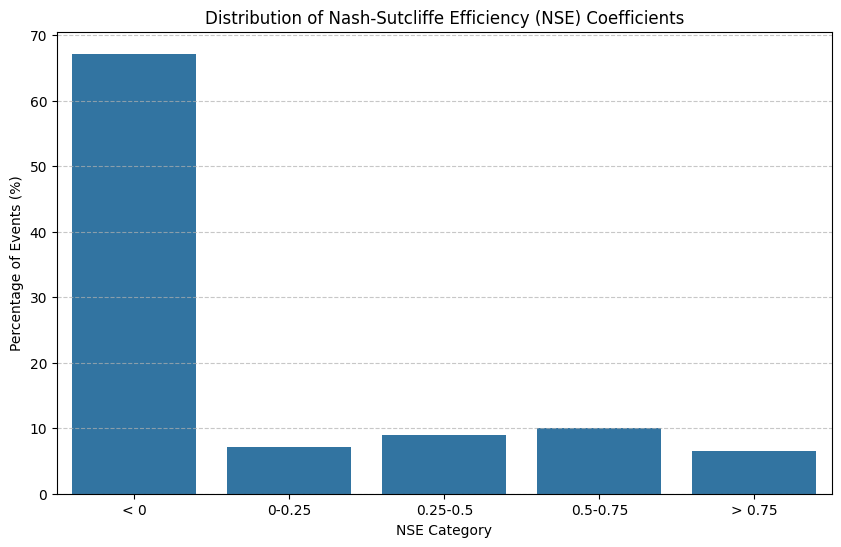


--- 2. Drivers of Model Performance (NSE) ---
Correlation of storm characteristics with NSE:
nse                         1.000000
ppt_spatial_variability     0.261289
constant_loss_mm_hr         0.135663
ppt_post_24h                0.110341
ppt_temporal_variability    0.103116
ppt_prior_14d               0.083154
ppt_post_6h                 0.082999
initial_loss_mm             0.082596
ppt_post_3h                 0.069333
total_precipitation_mm      0.064077
ppt_prior_7d                0.034429
ppt_prior_3d               -0.060485
ppt_prior_3h               -0.067941
ppt_prior_6h               -0.116015
peak_quickflow             -0.116693
ppt_dutation_min           -0.189650
tc_hr                      -0.191927
ppt_prior_24h              -0.211099
r_hr                       -0.311734
event_duration_min         -0.425379
total_ppt_after_peak_mm          NaN
response_min                     NaN
Name: nse, dtype: float64


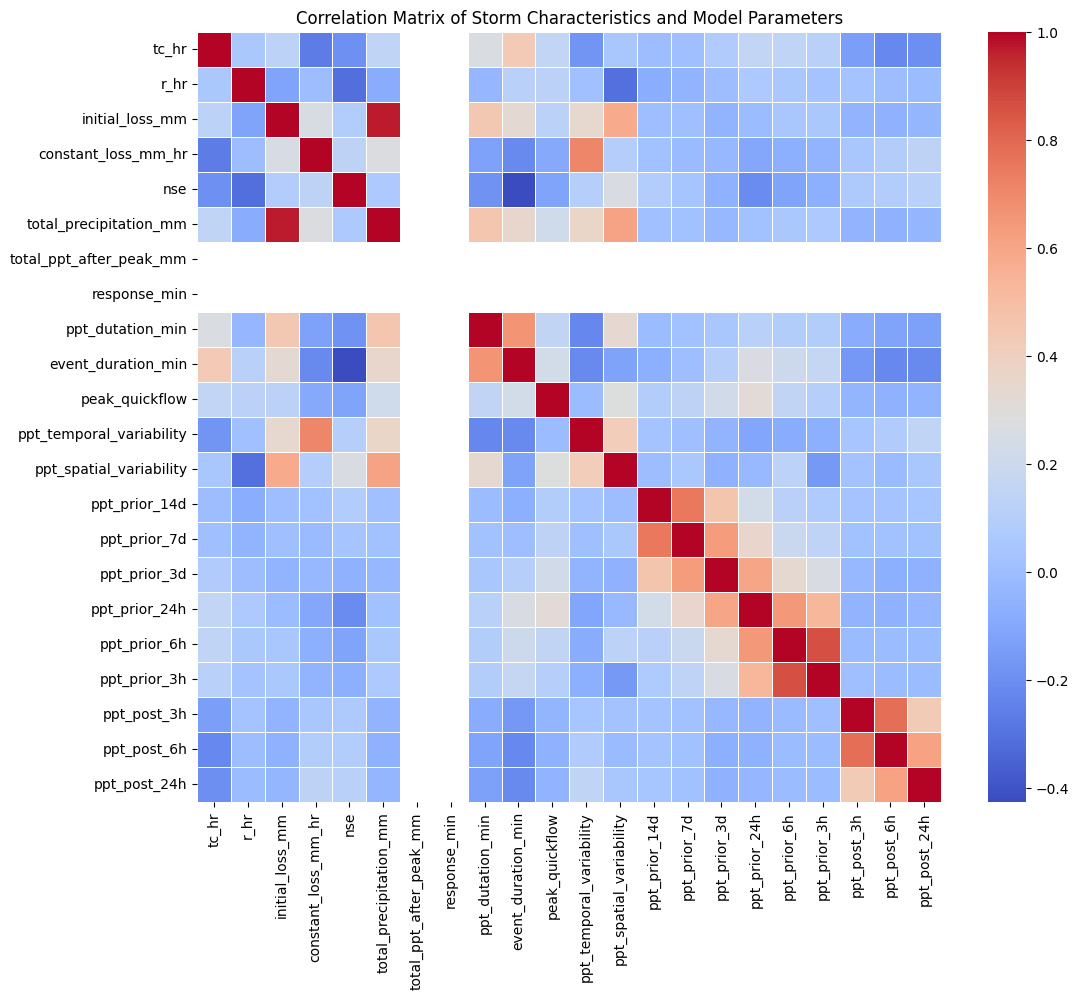

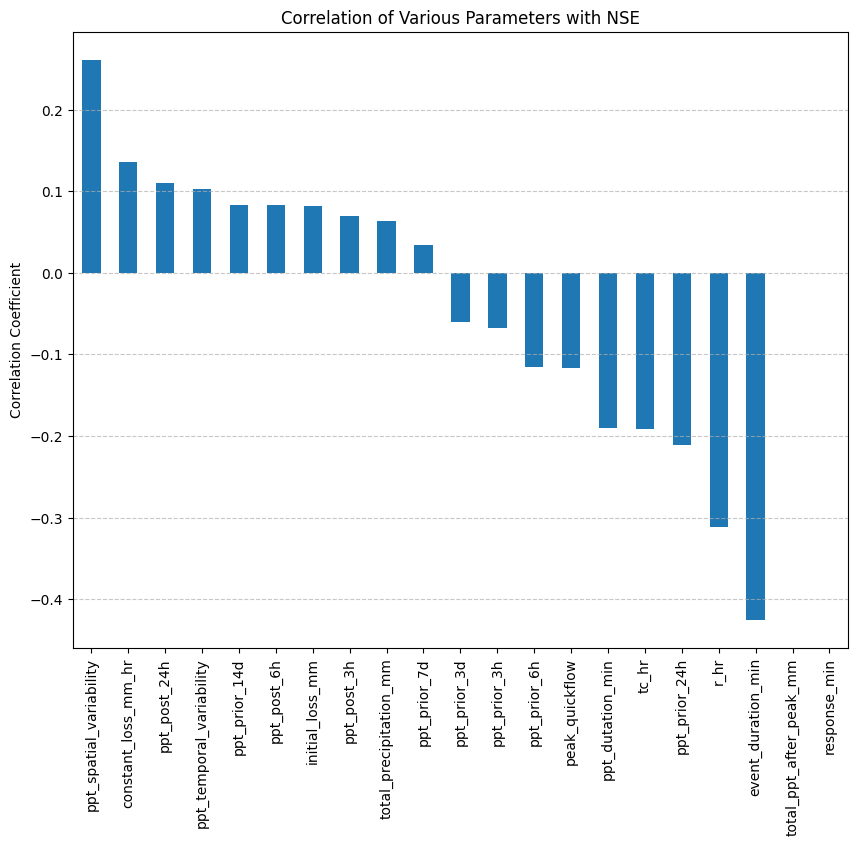


--- 3. Watershed Performance Analysis ---
Top performing watersheds by mean NSE (all events):
          mean_nse  event_count  nse_std_dev
ws_id                                       
03431060 -0.198643           40     0.925759
03353620 -0.208132          138     0.833781
03289200 -0.215290          123     0.857498
03301900 -0.307354          124     1.530277
03048900 -0.385396           17     1.094426
03246500 -0.397139           30     0.882610
03314000 -0.426234           17     0.781726
03254550 -0.504956           30     0.806753
03288190 -0.768521           57     1.336633
03353460 -1.067397           70     1.672638

Top performing watersheds by mean NSE (for events with NSE >= 0):
          mean_nse  event_count  nse_std_dev
ws_id                                       
03301900  0.646990           74     0.244725
03363500  0.568314            4     0.301482
03353460  0.563373           18     0.302509
03048500  0.531146            5     0.153770
03048900  0.511510          

/var/folders/6x/tz4_svyx1mv9mc68z3jl0_s00000gn/T/ipykernel_1691/753355039.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_watersheds.index, y=top_watersheds['mean_nse'], palette='viridis')


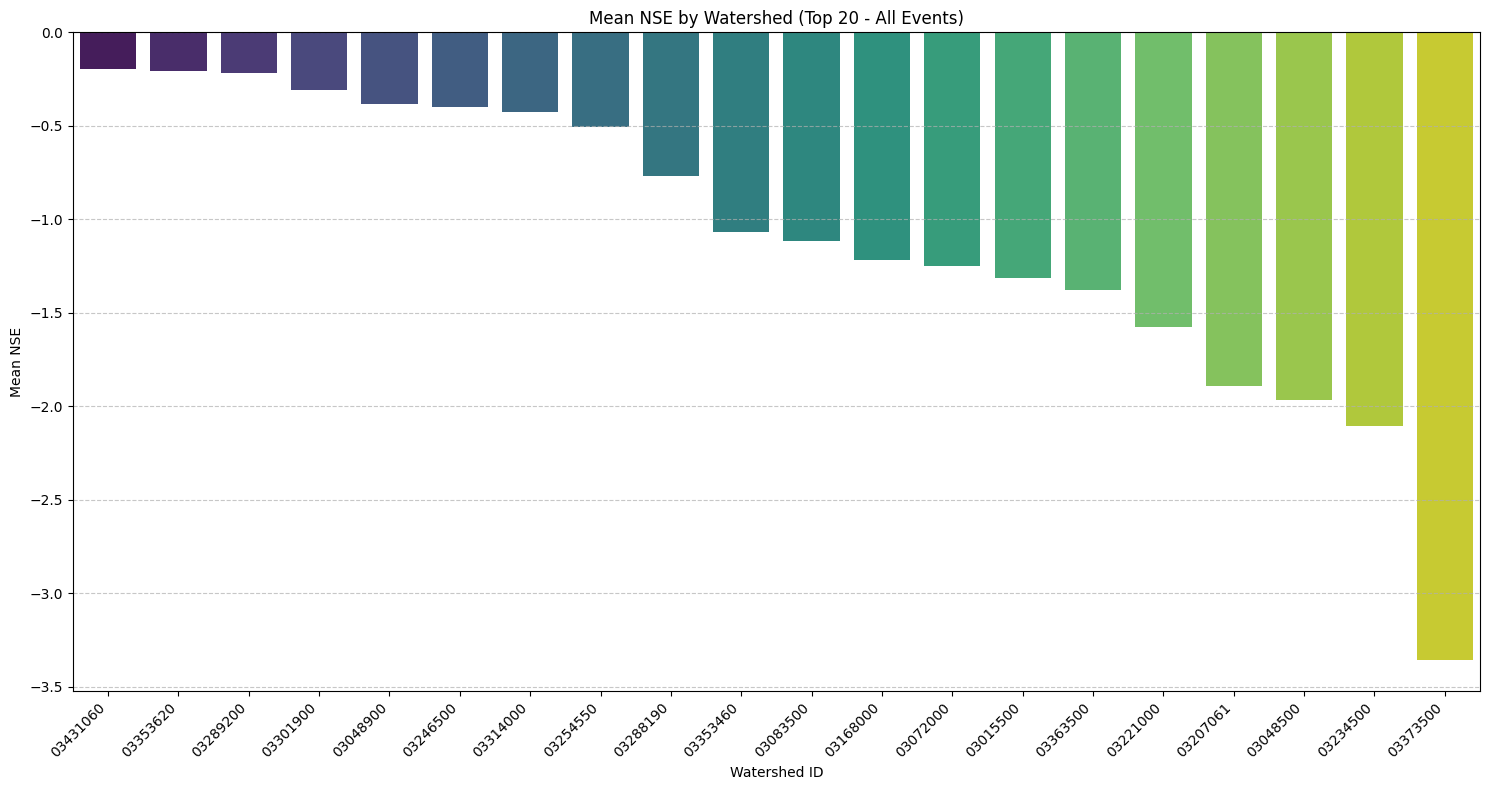


--- 4. Parameter Boundary Analysis ---

Analyzing Tc (Time of Concentration) with bounds (0.25, 10.0) hrs...

NSE statistics based on Tc boundary status:
                    count      mean       std       min       25%       50%  \
tc_boundary_status                                                            
Mid-Range           666.0 -0.712406  1.340529 -7.927206 -1.509109 -0.526228   
Near Lower Bound      2.0 -0.534326  0.050325 -0.569911 -0.552118 -0.534326   
Near Upper Bound    332.0 -0.994204  1.181305 -6.371136 -1.565450 -0.811533   

                         75%       max  
tc_boundary_status                      
Mid-Range           0.446634  0.967906  
Near Lower Bound   -0.516533 -0.498741  
Near Upper Bound   -0.167011  0.869552  


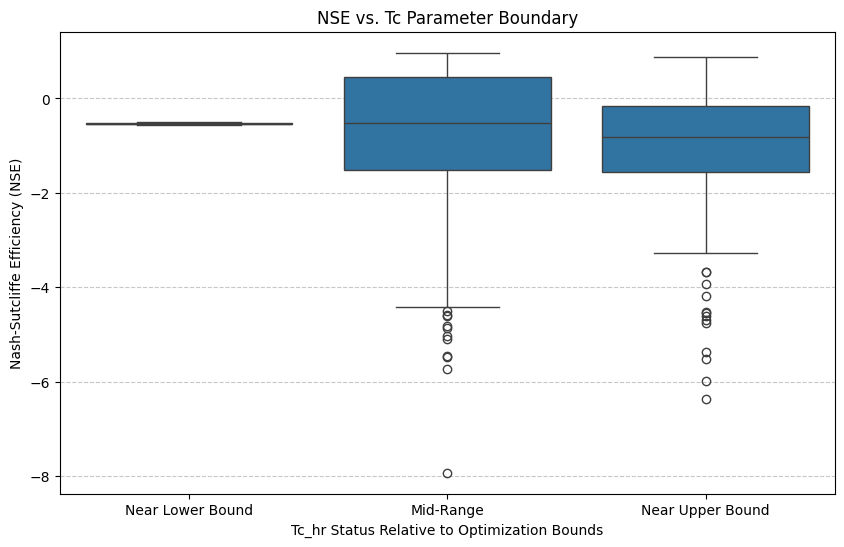


Analyzing R (Storage Coefficient) with bounds (0.25, 20)...

NSE statistics based on R boundary status:
                   count      mean       std       min       25%       50%  \
r_boundary_status                                                            
Mid-Range          595.0 -1.222083  1.176779 -5.732382 -1.820831 -1.167374   
Near Lower Bound   342.0 -0.058459  1.214992 -7.927206 -0.256630  0.355171   
Near Upper Bound    63.0 -0.928156  0.930124 -3.565810 -1.444426 -1.144087   

                        75%       max  
r_boundary_status                      
Mid-Range         -0.423079  0.907249  
Near Lower Bound   0.672141  0.967906  
Near Upper Bound  -0.131045  0.790027  


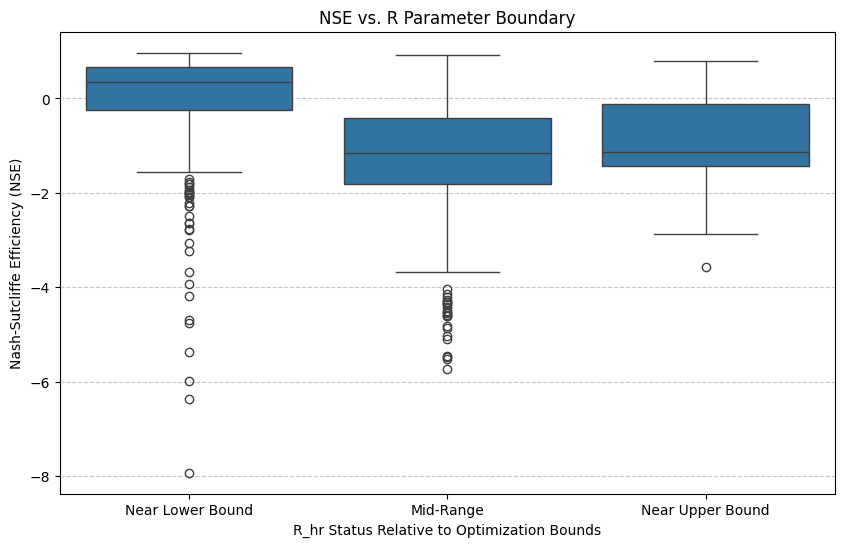

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_storm_results(df, tc_bounds=(0.25, 10), r_bounds=(0.1, 2.0)):
    """
    Analyzes the results of storm event modeling to understand NSE distribution,
    drivers of model performance, and watershed-specific results.

    Args:
        df (pd.DataFrame): DataFrame containing the storm event modeling results.
        tc_bounds (tuple): The (lower, upper) optimization bounds for tc_hr.
        r_bounds (tuple): The (lower, upper) optimization bounds for r_hr.
    """

    # --- 1. General Distribution of Optimized Results (NSE) ---
    print("--- 1. NSE Distribution Analysis ---")
    # ... (This section remains unchanged)
    bins = [-np.inf, 0, 0.25, 0.5, 0.75, 1.0]
    labels = ['< 0', '0-0.25', '0.25-0.5', '0.5-0.75', '> 0.75']
    df['nse_category'] = pd.cut(df['nse'], bins=bins, labels=labels, right=True)
    nse_distribution = df['nse_category'].value_counts(normalize=True).sort_index()
    print("Distribution of NSE values across categories:")
    print(nse_distribution * 100)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=nse_distribution.index, y=nse_distribution.values * 100)
    plt.title('Distribution of Nash-Sutcliffe Efficiency (NSE) Coefficients')
    plt.xlabel('NSE Category')
    plt.ylabel('Percentage of Events (%)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


    # --- 2. What Drives Good and Bad NSE? ---
    print("\n--- 2. Drivers of Model Performance (NSE) ---")
    # ... (This section remains unchanged)
    correlation_features = df.select_dtypes(include=np.number).drop(columns=['month', 'n_ppt_stations', 'missing_streamflow'], errors='ignore')
    correlation_matrix = correlation_features.corr()
    nse_correlations = correlation_matrix['nse'].sort_values(ascending=False)
    print("Correlation of storm characteristics with NSE:")
    print(nse_correlations)
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=.5)
    plt.title('Correlation Matrix of Storm Characteristics and Model Parameters')
    plt.show()
    plt.figure(figsize=(10, 8))
    nse_correlations.drop('nse').plot(kind='bar')
    plt.title('Correlation of Various Parameters with NSE')
    plt.ylabel('Correlation Coefficient')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


    # --- 3. Watershed-Specific Performance ---
    print("\n--- 3. Watershed Performance Analysis ---")
    # ... (This section remains unchanged)
    watershed_performance = df.groupby('ws_id')['nse'].agg(['mean', 'count', 'std']).sort_values(by='mean', ascending=False)
    watershed_performance.rename(columns={'mean': 'mean_nse', 'count': 'event_count', 'std': 'nse_std_dev'}, inplace=True)
    print("Top performing watersheds by mean NSE (all events):")
    print(watershed_performance.head(10))
    print("\nTop performing watersheds by mean NSE (for events with NSE >= 0):")
    df_positive_nse = df[df['nse'] >= 0].copy()
    if not df_positive_nse.empty:
        watershed_performance_positive = df_positive_nse.groupby('ws_id')['nse'].agg(['mean', 'count', 'std']).sort_values(by='mean', ascending=False)
        watershed_performance_positive.rename(columns={'mean': 'mean_nse', 'count': 'event_count', 'std': 'nse_std_dev'}, inplace=True)
        print(watershed_performance_positive.head(10))
    else:
        print("No events with NSE >= 0 found.")
    plt.figure(figsize=(15, 8))
    top_watersheds = watershed_performance.head(20)
    sns.barplot(x=top_watersheds.index, y=top_watersheds['mean_nse'], palette='viridis')
    plt.title('Mean NSE by Watershed (Top 20 - All Events)')
    plt.xlabel('Watershed ID')
    plt.ylabel('Mean NSE')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


    # --- 4. Parameter Boundary Analysis ---
    print("\n--- 4. Parameter Boundary Analysis ---")

    # MODIFICATION: Check both lower and upper bounds for Tc and R
    # Define thresholds as a small percentage of the total range
    tc_lower_thresh = tc_bounds[0] + 0.01 * (tc_bounds[1] - tc_bounds[0])
    tc_upper_thresh = tc_bounds[1] - 0.01 * (tc_bounds[1] - tc_bounds[0])
    r_lower_thresh = r_bounds[0] + 0.05 * (r_bounds[1] - r_bounds[0])
    r_upper_thresh = r_bounds[1] - 0.05 * (r_bounds[1] - r_bounds[0])

    # --- Tc Analysis ---
    print(f"\nAnalyzing Tc (Time of Concentration) with bounds {tc_bounds} hrs...")
    conditions_tc = [
        df['tc_hr'] <= tc_lower_thresh,
        df['tc_hr'] >= tc_upper_thresh
    ]
    choices_tc = ['Near Lower Bound', 'Near Upper Bound']
    df['tc_boundary_status'] = np.select(conditions_tc, choices_tc, default='Mid-Range')
    
    print("\nNSE statistics based on Tc boundary status:")
    print(df.groupby('tc_boundary_status')['nse'].describe())

    plt.figure(figsize=(10, 6))
    sns.boxplot(x='tc_boundary_status', y='nse', data=df, order=['Near Lower Bound', 'Mid-Range', 'Near Upper Bound'])
    plt.title('NSE vs. Tc Parameter Boundary')
    plt.xlabel('Tc_hr Status Relative to Optimization Bounds')
    plt.ylabel('Nash-Sutcliffe Efficiency (NSE)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # --- R Analysis ---
    print(f"\nAnalyzing R (Storage Coefficient) with bounds {r_bounds}...")
    conditions_r = [
        df['r_hr'] <= r_lower_thresh,
        df['r_hr'] >= r_upper_thresh
    ]
    choices_r = ['Near Lower Bound', 'Near Upper Bound']
    df['r_boundary_status'] = np.select(conditions_r, choices_r, default='Mid-Range')
    
    print("\nNSE statistics based on R boundary status:")
    print(df.groupby('r_boundary_status')['nse'].describe())

    plt.figure(figsize=(10, 6))
    sns.boxplot(x='r_boundary_status', y='nse', data=df, order=['Near Lower Bound', 'Mid-Range', 'Near Upper Bound'])
    plt.title('NSE vs. R Parameter Boundary')
    plt.xlabel('R_hr Status Relative to Optimization Bounds')
    plt.ylabel('Nash-Sutcliffe Efficiency (NSE)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


if __name__ == '__main__':
    TC_BOUNDS = (0.25, 10.0)
    R_BOUNDS = (0.25, 20)
    analyze_storm_results(optimized_results_merged, tc_bounds=TC_BOUNDS, r_bounds=R_BOUNDS)


**Conclusion:**
This script provides a comprehensive analysis of storm event modeling results, focusing on the distribution of Nash-Sutcliffe Efficiency (NSE), the drivers of model performance, watershed-specific results, and the impact of parameter boundaries on model performance. 

While it was not possible to securily draw a pattern between bad NSE with sotrm event characterists, the fixed lower boundaries for $R$ appear to have best fit to the storm event modeled. Therefore, allowing it to go even lower, may improve the model perfomance. 

We also increase the upper boundary for $T_c$ to allow for greater seach window, in an attempt to improve model perfomance.

NameError: name 'dist_meters' is not defined

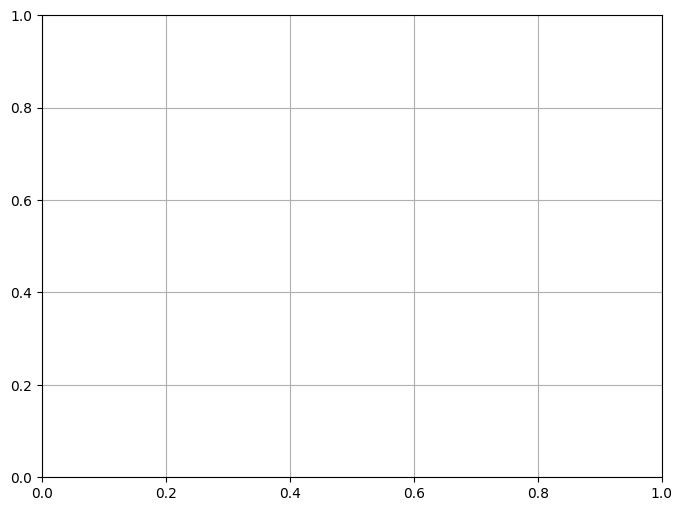

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_alpha(0)


ax.grid('on', zorder=0)
im = ax.imshow(dist_meters, extent=grid.extent, zorder=2,
                 cmap='cubehelix_r')
# Add a colorbar specific to the first axis
fig.colorbar(im, ax=ax, label='Distance to outlet (meters)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Flow Distance for watershed {sample_ws_id}', size=14)

# Ws id 03298150

In [ ]:

event_metada = filtered_storm_events_metada[filtered_storm_events_metada['ws_id'] == sample_ws_id]

In [448]:
# Define model parameters
# Choose the first event of selected watershed
event_metada_df = filtered_storm_events_metada[filtered_storm_events_metada['ws_id'] == sample_ws_id]
event_metada = event_metada_df.sample().iloc[0]
df = lined_up_data.loc[event_metada['event_start']:event_metada['event_end']].copy()
distance_grid = dist_meters.copy()
cell_area = avg_res**2
delta_t=15*30 

basin_length = geo_characteristics.loc[geo_characteristics['Station ID'] == sample_ws_id, 'Basin Length'].values[0]
slope_10_85 = geo_characteristics.loc[geo_characteristics['Station ID'] == sample_ws_id, 'Flowpath 10-85 Slope'].values[0]


In [449]:
model = ModClarkModel(df=df, distance_grid=distance_grid,cell_area=cell_area, delta_t=delta_t)

In [450]:
optmized_params_random_bounds = model.run_optimization()
optmized_params_computed_bounds = model.run_optimization(basin_length_m=basin_length, slope_10_85=slope_10_85)


--- 🚀 Starting Optimization ---
Using fixed, default search bounds.
differential_evolution step 1: f(x)= 2.0269066604374952
differential_evolution step 2: f(x)= 1.734008874554041
differential_evolution step 3: f(x)= 1.734008874554041
differential_evolution step 4: f(x)= 1.734008874554041
differential_evolution step 5: f(x)= 1.734008874554041
differential_evolution step 6: f(x)= 1.515097865918675
differential_evolution step 7: f(x)= 1.515097865918675
differential_evolution step 8: f(x)= 1.515097865918675
differential_evolution step 9: f(x)= 1.515097865918675
differential_evolution step 10: f(x)= 1.515097865918675
differential_evolution step 11: f(x)= 1.353526303072027
differential_evolution step 12: f(x)= 1.353526303072027
differential_evolution step 13: f(x)= 1.295260958668826
differential_evolution step 14: f(x)= 0.9897151333081192
differential_evolution step 15: f(x)= 0.7655518449242587
differential_evolution step 16: f(x)= 0.7655518449242587
differential_evolution step 17: f(x)= 0.7

In [451]:
tc = optmized_params_random_bounds['optimized_tc_hr']*3600
r = optmized_params_random_bounds['optimized_r_hr']*3600
initial_loss = optmized_params_random_bounds['optimized_initial_loss_mm']/1000
constant_loss_rate = (optmized_params_random_bounds['optimized_constant_loss_mm_hr']/1000)/3600
sim_flow, excess_ppt = model.simulate(tc=tc, r=r, initial_loss=initial_loss, constant_loss_rate=constant_loss_rate)

In [452]:
df_hydrograph = df.copy()
df_hydrograph['simulated_flow'] = sim_flow
df_hydrograph['excess_precip'] = excess_ppt
df_hydrograph['date'] = df_hydrograph.index
df_hydrograph['ppt_mm'] = df_hydrograph['height']*1000

event_str = df.index[0].strftime('%d %B of %Y')

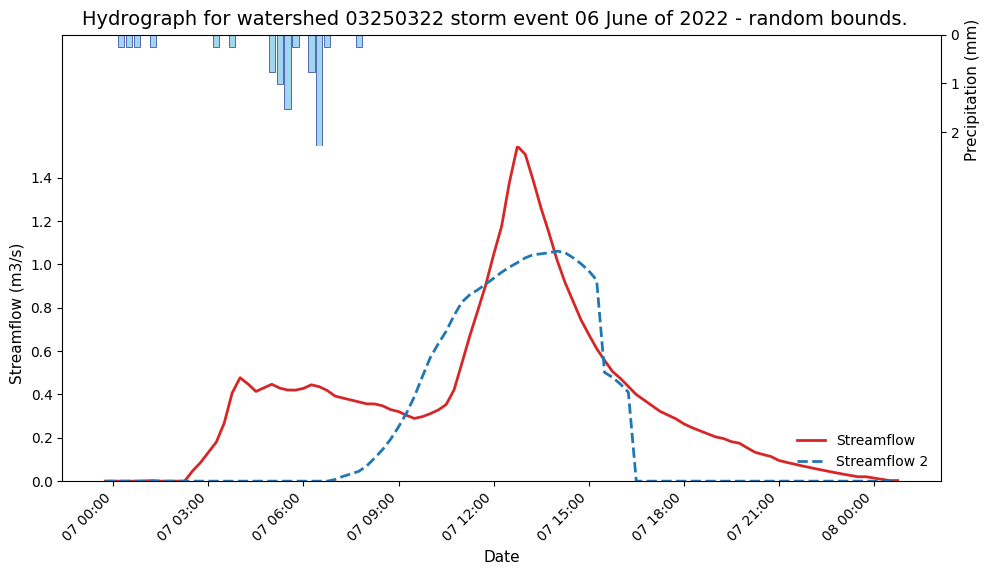

In [453]:
hydrograph2(
    df=df_hydrograph,
    streamflow_col='quickflow',
    streamflow2_col='simulated_flow',
    time_col='date',
    precip_col='ppt_mm',
    precip2_col='excess_precip',
    P_units='mm',
    S_units='m3/s',
    title=f"Hydrograph for watershed {sample_ws_id} storm event {event_str} - random bounds."
)

In [454]:
nonna = filtered_storm_events_metada.dropna(subset=['ppt_temporal_variability']).copy()
nonna.iloc[nonna['ppt_temporal_variability'].idxmin()]

event_start                 2018-03-01 02:15:00+00:00
event_end                   2018-03-05 18:00:00+00:00
month                                               3
ppt_start                   2018-03-01 02:45:00+00:00
ppt_end                     2018-03-01 12:00:00+00:00
total_precipitation_mm                       8.340637
total_ppt_after_peak_mm                           0.0
response_min                                     30.0
ppt_dutation_min                                  570
event_duration_min                               6720
peak_quickflow                             101.974672
ppt_temporal_variability                     0.000161
ppt_spatial_variability                      0.000014
n_ppt_stations                                      2
missing_streamflow                                  0
ppt_prior_14d                                0.022085
ppt_prior_7d                                 0.008541
ppt_prior_3d                                 0.001698
ppt_prior_24h               

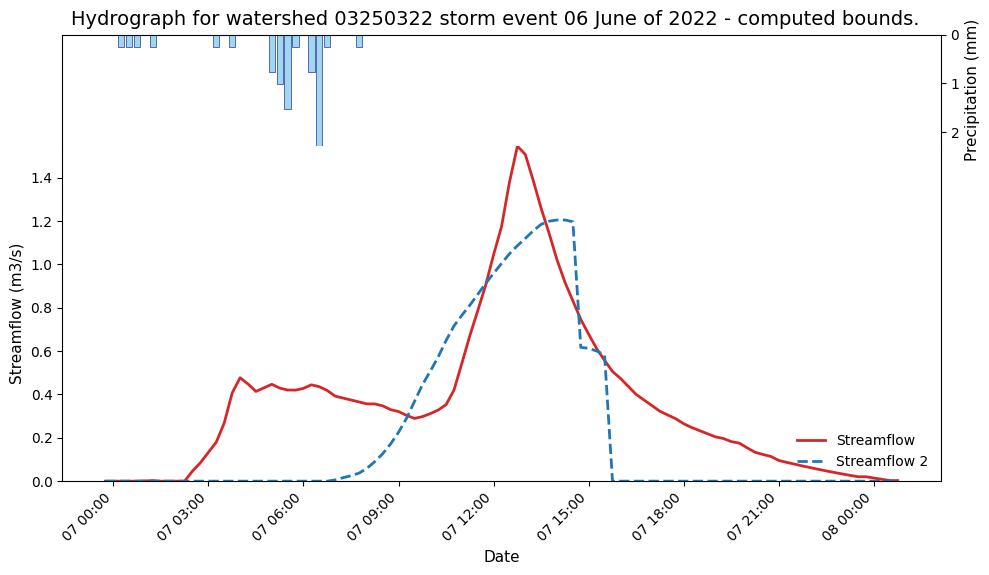

In [455]:
tc2 = optmized_params_computed_bounds['optimized_tc_hr']*3600
r2 = optmized_params_computed_bounds['optimized_r_hr']*3600
initial_loss2 = optmized_params_computed_bounds['optimized_initial_loss_mm']/1000
constant_loss_rate2 = (optmized_params_computed_bounds['optimized_constant_loss_mm_hr']/1000)/3600
sim_flow2, excess_ppt2 = model.simulate(tc=tc2, r=r2, initial_loss=initial_loss2, constant_loss_rate=constant_loss_rate2)

df_hydrograph2 = df.copy()
df_hydrograph2['simulated_flow'] = sim_flow2
df_hydrograph2['excess_precip'] = excess_ppt2
df_hydrograph2['date'] = df_hydrograph2.index
df_hydrograph2['ppt_mm'] = df_hydrograph2['height']*1000

event_str = df.index[0].strftime('%d %B of %Y')

hydrograph2(
    df=df_hydrograph2,
    streamflow_col='quickflow',
    streamflow2_col='simulated_flow',
    time_col='date',
    precip_col='ppt_mm',
    precip2_col='excess_precip',
    P_units='mm',
    S_units='m3/s',
    title=f"Hydrograph for watershed {sample_ws_id} storm event {event_str} - computed bounds."
)